In [1]:
%load_ext autoreload
%autoreload 2

In [28]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from matplotlib.lines import Line2D

In [3]:
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'figure.titlesize': 18,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False
})

tol_bright = [
    '#4477AA',  # blue
    '#EE6677',  # red
    '#228833',  # green
    '#CCBB44',  # yellow
    '#66CCEE',  # cyan
    '#AA3377',  # purple
    '#BBBBBB',  # grey
]

label_mapping = {
    "AS": "AS",
    "SG-ICM\ncalibrated": "SCALE calibrated",
    "SG-ICM\nflipped": "SCALE flipped",
    "SG-ICM\nlearning rho": "SCALE",
    "SG calibrated\n(0.01, 20, 20)": "SG calibrated",
    "SG flipped\n(20 0.01 0.01)": "SG flipped",
    # Handle potential variations from multiround script
    "SG-ICM calibrated": "SCALE calibrated",
    "SG-ICM learning rho": "SCALE",
    "landmarks_corr": "SCALE" # Internal key sometimes used
}

hue_order = [
    'AS',
    'SG calibrated',
    'SCALE calibrated',
    'SCALE',
    'SG flipped',
    'SCALE flipped'
]

palette = {
    "AS": tol_bright[3],
    "SCALE calibrated": tol_bright[0],
    "SCALE flipped": tol_bright[1],
    "SCALE": tol_bright[2],
    "SG calibrated": tol_bright[4],
    "SG flipped": tol_bright[5]
}

rho_colors = plt.cm.viridis(np.linspace(0.2, 0.9, 3))

In [5]:
def load_and_process_data(rho_update_folder, rho_update_multiround_folder):
    # Paths (using those provided in the prompt)
    rho_update_results_path = Path(rho_update_folder)
    rho_update_multiround_results_path = Path(rho_update_multiround_folder)

    output_dir = Path("final_figures")
    output_dir.mkdir(exist_ok=True)

    # Load Single Round
    ru_rho_histories = np.load(rho_update_results_path / "rho_histories.npy", allow_pickle=True)
    ru_results = pd.read_csv(rho_update_results_path / "results.csv")

    # Load Multi Round
    ru_multiround_histories = np.load(rho_update_multiround_results_path / "rho_histories.npy", allow_pickle=True)
    ru_multiround_results = pd.read_csv(rho_update_multiround_results_path / "results.csv")

    # Clean Labels in DataFrames
    ru_results['condition_label'] = ru_results['condition_label'].map(label_mapping).fillna(ru_results['condition_label'])

    ru_multiround_results['condition_label'] = ru_multiround_results['condition_label'].map(label_mapping).fillna(ru_multiround_results['condition_label'])

    return ru_results, ru_rho_histories, ru_multiround_results, ru_multiround_histories, output_dir

ru_res, ru_hist, mr_res, mr_hist, output_dir = load_and_process_data("results_20260123_155845", "results_multiround_20260123_155907")

/var/folders/j1/yztn44qj3cx5txyykg20nctr0000gn/T/ipykernel_21660/679821764.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', title=None, frameon=False)


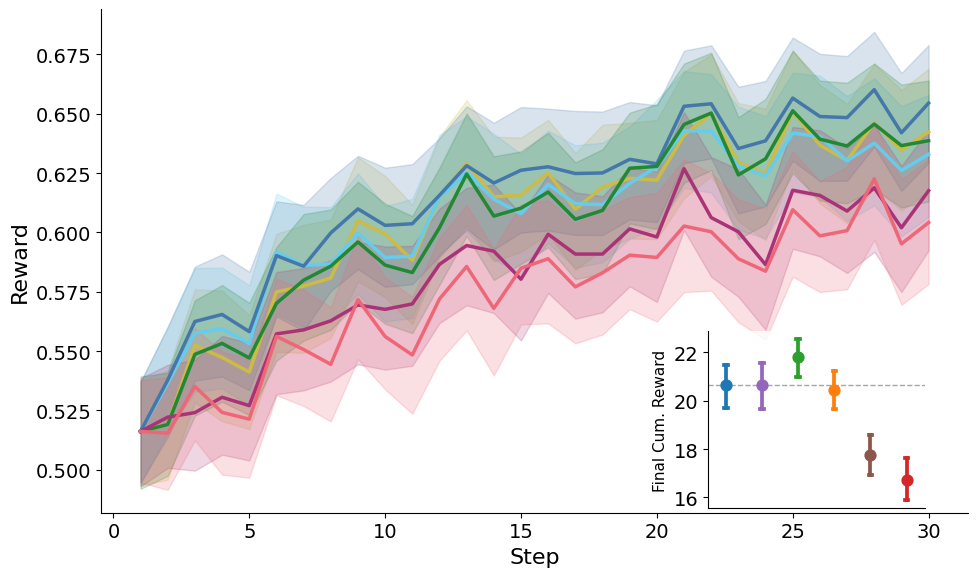

In [20]:
def plot_reward_composite(df, output_path):
    """
    Fig 1: Reward Curve with Inset for Final Cumulative Reward
    """
    plot_df = df.copy()

    # Filter only relevant conditions present in data
    available_conditions = [c for c in hue_order if c in plot_df['condition_label'].unique()]

    fig, ax = plt.subplots(figsize=(10, 6))

    # Main: Reward over time
    sns.lineplot(
        data=plot_df,
        x="Step",
        y="reward",
        hue="condition_label",
        hue_order=available_conditions,
        palette=palette,
        errorbar="ci",
        linewidth=2.5,
        ax=ax,
        legend=False,
    )
    ax.set_ylabel("Reward")
    ax.set_xlabel("Step")

    ax_ins = ax.inset_axes([0.7, 0.01, 0.25, 0.35])

    # Get last step per seed per condition
    group_cols = ["seed", "condition_label"]
    final_step_df = plot_df.loc[plot_df.groupby(group_cols)["Step"].idxmax()].copy()

    sns.pointplot(
        data=final_step_df,
        x="condition_label",
        y="cumulative_reward",
        order=available_conditions,
        hue="condition_label",
        legend=False,
        errorbar=('ci', 95),
        linestyle='none',
        capsize=0.1,
        ax=ax_ins,
        # markersize=0.7
    )

    # Add horizontal line for AS performance
    as_data = final_step_df[final_step_df['condition_label'] == 'AS']
    if not as_data.empty:
        as_mean = as_data['cumulative_reward'].mean()
        ax_ins.axhline(y=as_mean, color='gray', linestyle='--', linewidth=1, alpha=0.7, zorder=0)

    # Formatting Inset
    ax_ins.set_ylabel("Final Cum. Reward", fontsize=11)
    ax_ins.set_xlabel("")
    # Remove x-tick labels (colors match main legend) to save space
    ax_ins.set_xticklabels([])
    ax_ins.tick_params(axis='x', which='both', bottom=False)
    # ax_ins.set_title("", fontsize=11)

    # Semi-transparent background for inset to ensure readability over grid/lines
    ax_ins.patch.set_alpha(0.8)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved {output_path}")

# plot_reward_composite(ru_res, output_dir / "fig1_reward_composite.png")
plot_reward_composite(ru_res, output_dir / "fig1_reward_composite.svg")

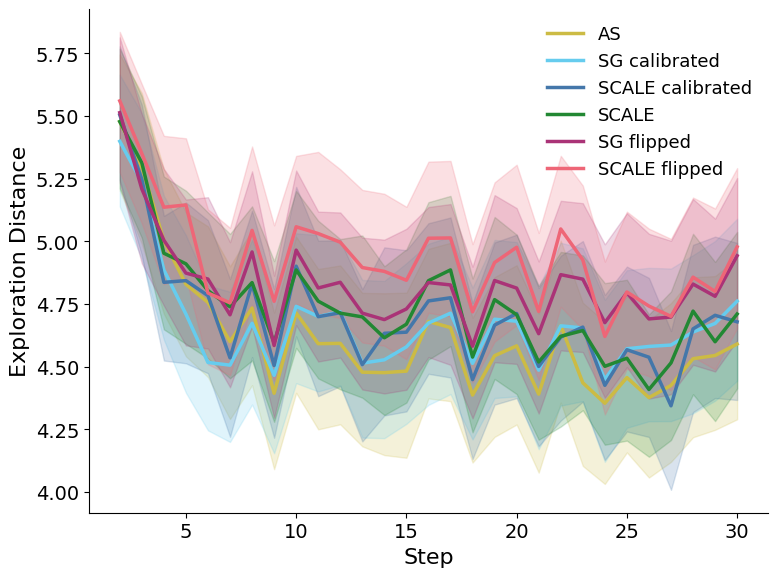

In [19]:
def plot_exploration_distance(df, output_path):
    plot_df = df.copy()
    # Remove step 0 or 1 if distance is zero/undefined usually
    plot_df = plot_df[plot_df["Step"] > 1]

    available_conditions = [c for c in hue_order if c in plot_df['condition_label'].unique()]

    fig, ax = plt.subplots(figsize=(8, 6))

    sns.lineplot(
        data=plot_df,
        x="Step",
        y="last_choice_distance_private",
        hue="condition_label",
        hue_order=available_conditions,
        palette=palette,
        errorbar="ci",
        linewidth=2.5,
        ax=ax
    )

    ax.set_ylabel("Exploration Distance")
    ax.set_xlabel("Step")
    ax.legend(loc='upper right', title=None)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved {output_path}")

plot_exploration_distance(ru_res, output_dir / "fig2_exploration_distance.svg")

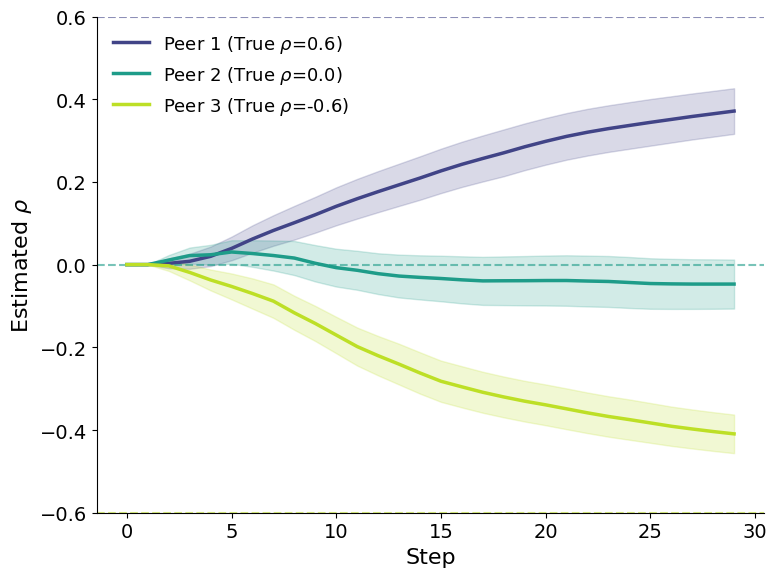

In [23]:
def plot_rho_estimation_single(rho_histories, output_path):
    target_keys = ["landmarks_corr", "SCALE"]

    relevant_histories = []
    for h in rho_histories:
        # Check if condition matches
        cond = h.get('condition') if isinstance(h, dict) else h.condition
        if cond in target_keys:
            hist = h.get('rho_history') if isinstance(h, dict) else h.rho_history
            relevant_histories.append(hist)

    if not relevant_histories:
        print("No rho histories found for SCALE/landmarks_corr")
        return

    stack = np.stack(relevant_histories, axis=0)

    # Calculate Mean and 95% CI
    mean_rho = np.mean(stack, axis=0) # (N_steps, 4)
    std_rho = np.std(stack, axis=0)
    n_samples = stack.shape[0]
    ci = 1.96 * std_rho / np.sqrt(n_samples)

    steps = np.arange(mean_rho.shape[0])
    true_rhos = [0.6, 0.0, -0.6] # Peer 1, 2, 3 (indices 1, 2, 3 in the array)

    fig, ax = plt.subplots(figsize=(8, 6))

    for i in range(3): # Peers 1 to 3
        idx = i + 1
        color = rho_colors[i]
        true_val = true_rhos[i]

        # Plot Mean
        # Update label to include true correlation
        ax.plot(steps, mean_rho[:, idx], color=color, linewidth=2.5,
                label=f"Peer {idx} (True $\\rho$={true_val})")

        # Plot CI
        ax.fill_between(steps,
                        mean_rho[:, idx] - ci[:, idx],
                        mean_rho[:, idx] + ci[:, idx],
                        color=color, alpha=0.2)

        # Plot True Rho (dashed)
        # Using a slightly darker version or same color dashed
        ax.axhline(true_val, color=color, linestyle='--', linewidth=1.5, alpha=0.6)

    ax.set_ylabel("Estimated $\\rho$")
    ax.set_xlabel("Step")
    ax.set_ylim(-0.6, 0.6)

    # Legend
    # Moved to upper right to avoid overlap (lines occupy -0.6 to 0.6)
    ax.legend(loc='upper left', title=None)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved {output_path}")

plot_rho_estimation_single(ru_hist, output_dir / "fig3_rho_estimation_single.svg")

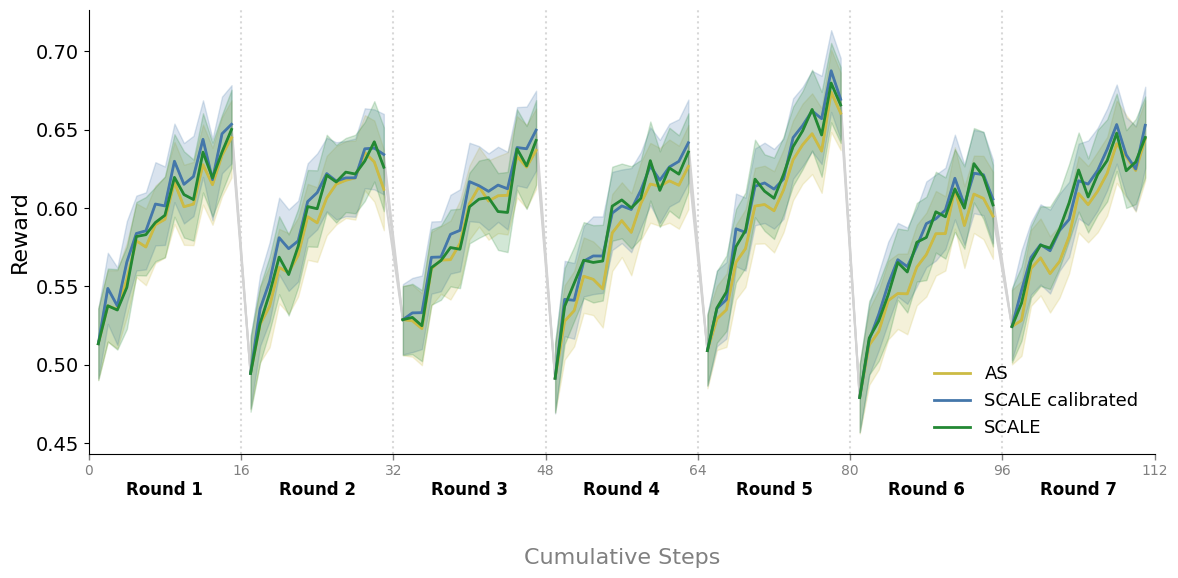

Saved final_figures/fig4_multiround_reward_continuous.svg


In [27]:
def plot_multiround_reward_continuous(df, output_path):
    plot_df = df.copy()

    # Calculate Global Step
    steps_per_round = plot_df["Step"].max() + 1
    plot_df["GlobalStep"] = plot_df["Round"] * steps_per_round + plot_df["Step"]

    available_conditions = [c for c in hue_order if c in plot_df['condition_label'].unique()]

    fig, ax = plt.subplots(figsize=(12, 6))

    # Create a gray palette for the background lines
    gray_palette = {k: '#D3D3D3' for k in available_conditions} # LightGray

    # 1. Plot continuous Gray lines (background/connectors)
    sns.lineplot(
        data=plot_df,
        x="GlobalStep",
        y="reward",
        hue="condition_label",
        hue_order=available_conditions,
        palette=gray_palette,
        estimator='mean',
        errorbar=None,
        linewidth=1.5,
        legend=False,
        ax=ax,
        zorder=1
    )

    # 2. Plot colored segments per Round
    unique_rounds = sorted(plot_df["Round"].unique())
    n_rounds = len(unique_rounds)

    for r in unique_rounds:
        round_df = plot_df[plot_df["Round"] == r]

        # Only show legend for the first round iteration to avoid duplicates
        show_legend = (r == 0)

        sns.lineplot(
            data=round_df,
            x="GlobalStep",
            y="reward",
            hue="condition_label",
            hue_order=available_conditions,
            palette=palette,
            errorbar="ci",
            linewidth=2,
            ax=ax,
            legend=show_legend,
            zorder=2
        )

    # 3. Axis Formatting

    # Remove space before first round
    max_step = plot_df["GlobalStep"].max()
    ax.set_xlim(0, max_step)

    # Configure Major Ticks (Step Numbers at Round Boundaries)
    boundary_ticks = [r * steps_per_round for r in range(n_rounds + 1)]
    ax.set_xticks(boundary_ticks)
    ax.set_xticklabels(boundary_ticks, fontsize=10, color='gray') # Step labels

    # Configure Minor Ticks (Round Labels in the Middle)
    center_locs = [r * steps_per_round + (steps_per_round / 2) for r in range(n_rounds)]
    center_labels = [f"Round {r + 1}" for r in range(n_rounds)]

    ax.set_xticks(center_locs, minor=True)
    ax.set_xticklabels(center_labels, minor=True, fontsize=12, fontweight='bold')

    # Styling Ticks
    # Major (Steps): small tick lines, labeled closer to axis
    ax.tick_params(axis='x', which='major', length=4, width=1, colors='gray', direction='out')

    # Minor (Rounds): no tick lines, labeled further down (pad=20)
    ax.tick_params(axis='x', which='minor', length=0, pad=20, colors='black')

    # Vertical dividers at boundaries
    for r in range(1, n_rounds):
        ax.axvline(r * steps_per_round, color='gray', linestyle=':', alpha=0.3, zorder=0)

    ax.set_xlabel("Cumulative Steps", labelpad=35, color='gray')
    ax.set_ylabel("Reward")
    ax.legend(loc='lower right', title=None)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved {output_path}")

plot_multiround_reward_continuous(mr_res, output_dir / "fig4_multiround_reward_continuous.svg")

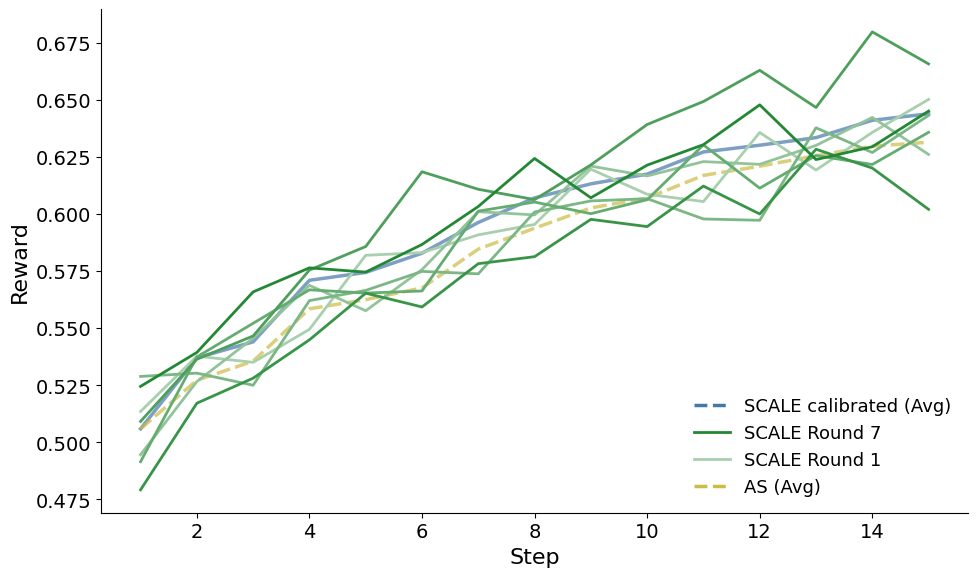

Saved final_figures/fig7_multiround_overlay.svg


In [36]:
def plot_multiround_learning_overlay(df, output_path):
    # 1. Setup Data
    target_cond = "SCALE"
    baselines = ["AS", "SCALE calibrated"]

    # Filter
    df_bases = df[df["condition_label"].isin(baselines)].copy()
    df_scale = df[df["condition_label"] == target_cond].copy()

    if df_scale.empty: return

    fig, ax = plt.subplots(figsize=(10, 6))

    # 2. Plot Baselines (Aggregated across all rounds/seeds)
    # This gives a single 'mean' curve per baseline condition
    sns.lineplot(
        data=df_bases,
        x="Step",
        y="reward",
        hue="condition_label",
        palette=palette,
        style="condition_label",
        dashes=True,
        linewidth=2.5,
        alpha=0.7,
        errorbar=None,
        ax=ax,
        zorder=2,
        legend=False
    )

    # 3. Plot SCALE Rounds with Gradient
    unique_rounds = sorted(df_scale["Round"].unique())
    n_rounds = len(unique_rounds)

    # Create a gradient from light green to dark green (SCALE's color is #228833)
    # We skip the very first lightest colors to ensure visibility
    cmap = sns.light_palette("#228833", n_colors=n_rounds + 3)[3:]

    for i, r in enumerate(unique_rounds):
        # Filter for this round
        dfr = df_scale[df_scale["Round"] == r]

        # We calculate mean per step for the line (averaging over seeds)
        mean_r = dfr.groupby("Step")["reward"].mean()

        ax.plot(
            mean_r.index,
            mean_r.values,
            color=cmap[i],
            linewidth=2,
            zorder=3,
            clip_on=False
        )

    # 4. Custom Legend
    # Order requested: SCALE calibrated -> SCALE Round N -> ... -> SCALE Round 1 -> AS
    handles = []

    # 1. SCALE calibrated
    if "SCALE calibrated" in baselines:
        color = palette["SCALE calibrated"]
        h_sc = Line2D([0], [0], color=color, linestyle='--', linewidth=2.5, label="SCALE calibrated (Avg)")
        handles.append(h_sc)

    # 2. SCALE Round N (Last)
    # Corresponds to the last color used in the loop
    h_last = Line2D([0], [0], color=cmap[n_rounds - 1], linewidth=2, label=f"SCALE Round {n_rounds}")
    handles.append(h_last)

    # 3. SCALE Round 1 (First)
    h_first = Line2D([0], [0], color=cmap[0], linewidth=2, label=f"SCALE Round 1")
    handles.append(h_first)

    # 4. AS
    if "AS" in baselines:
        color = palette["AS"]
        h_as = Line2D([0], [0], color=color, linestyle='--', linewidth=2.5, label="AS (Avg)")
        handles.append(h_as)

    ax.legend(handles=handles, loc='lower right')

    # ax.set_title("Learning Dynamics: Rounds Overlay")
    ax.set_xlabel("Step")  #  (within Round)
    ax.set_ylabel("Reward")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved {output_path}")

plot_multiround_learning_overlay(mr_res, output_dir / "fig7_multiround_overlay.svg")

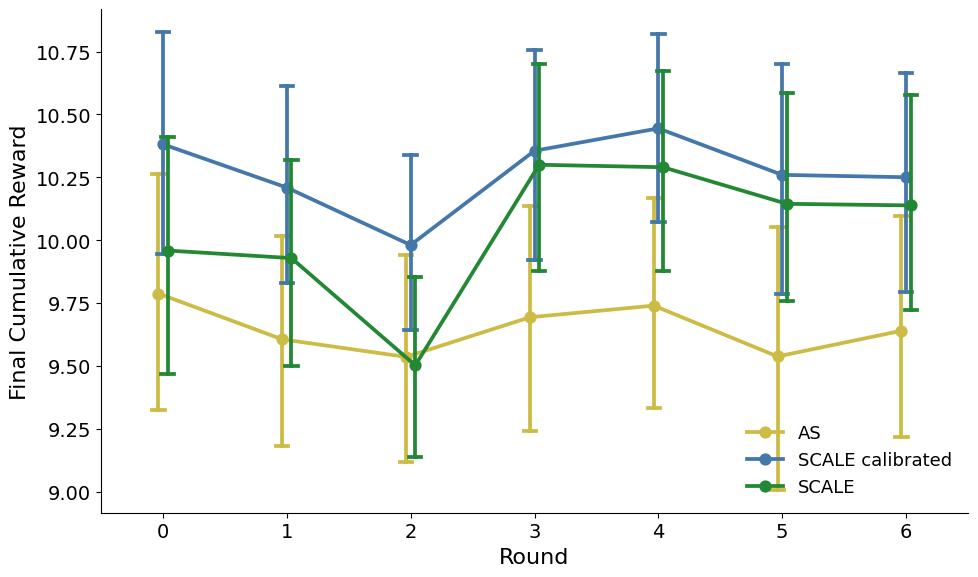

Saved final_figures/fig5_multiround_improvement.svg


In [37]:
def plot_multiround_improvement(df, output_path):
    plot_df = df.copy()

    # Get final step of each round per seed
    idx_max_step = plot_df.groupby(["seed", "Round", "condition_label"])["Step"].idxmax()
    summary = plot_df.loc[idx_max_step]

    available_conditions = [c for c in hue_order if c in summary['condition_label'].unique()]

    fig, ax = plt.subplots(figsize=(10, 6))

    sns.pointplot(
        data=summary,
        x="Round",
        y="cumulative_reward",
        hue="condition_label",
        hue_order=available_conditions,
        palette=palette,
        dodge=True,
        errorbar=('ci', 95),
        capsize=0.1,
        ax=ax
    )

    ax.set_ylabel("Final Cumulative Reward")
    ax.set_xlabel("Round")
    ax.legend(loc='lower right', title=None)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved {output_path}")

plot_multiround_improvement(mr_res, output_dir / "fig5_multiround_improvement.svg")

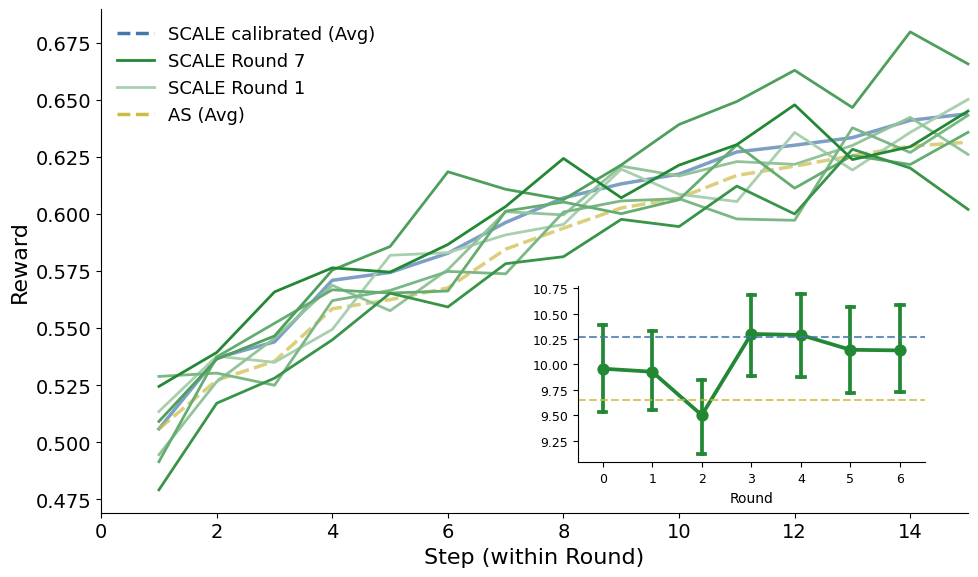

Saved final_figures/fig7_multiround_overlay2.svg


In [49]:
def plot_multiround_learning_overlay2(df, output_path):
    """
    Fig 7: Alternative Multi-round view.
    X-axis: Step (0..max_step in a round).
    Main Lines:
      - Dashed averages for Baselines (AS, SCALE calibrated).
      - Gradient lines for SCALE condition (Round 1..N).
    Inset:
      - Evolution of Cumulative Reward over Rounds for SCALE.
      - Horizontal reference lines for Baselines.
    """
    if df.empty: return

    # 1. Setup Data
    target_cond = "SCALE"
    baselines = ["AS", "SCALE calibrated"]

    # Filter
    df_bases = df[df["condition_label"].isin(baselines)].copy()
    df_scale = df[df["condition_label"] == target_cond].copy()

    if df_scale.empty: return

    fig, ax = plt.subplots(figsize=(10, 6))

    # 2. Plot Baselines (Aggregated across all rounds/seeds)
    # This gives a single 'mean' curve per baseline condition
    sns.lineplot(
        data=df_bases,
        x="Step",
        y="reward",
        hue="condition_label",
        palette=palette,
        style="condition_label",
        dashes=True,
        linewidth=2.5,
        alpha=0.7,
        errorbar=None,
        ax=ax,
        zorder=2,
        legend=False
    )

    # 3. Plot SCALE Rounds with Gradient
    unique_rounds = sorted(df_scale["Round"].unique())
    n_rounds = len(unique_rounds)

    # Create a gradient from light green to dark green (SCALE's color is #228833)
    # We skip the very first lightest colors to ensure visibility
    cmap = sns.light_palette("#228833", n_colors=n_rounds + 3)[3:]

    for i, r in enumerate(unique_rounds):
        # Filter for this round
        dfr = df_scale[df_scale["Round"] == r]

        # We calculate mean per step for the line (averaging over seeds)
        mean_r = dfr.groupby("Step")["reward"].mean()

        ax.plot(
            mean_r.index,
            mean_r.values,
            color=cmap[i],
            linewidth=2,
            zorder=3,
            clip_on=False  # Ensure the start at step 0 is not clipped
        )

    # 4. Inset: Final Cumulative Reward vs Round
    # Position: [x, y, width, height] relative to parent axes (Bottom Right)
    ax_ins = ax.inset_axes([0.55, 0.1, 0.4, 0.35])

    # Prepare Data for Inset (Last step of each round per seed)
    idx_max = df.groupby(["seed", "Round", "condition_label"])["Step"].idxmax()
    final_df = df.loc[idx_max]

    # Plot SCALE trend (Improvement over rounds) using pointplot (catplot style)
    scale_trend_df = final_df[final_df["condition_label"] == target_cond]
    sns.pointplot(
        data=scale_trend_df,
        x="Round",
        y="cumulative_reward",
        color=palette[target_cond],
        markers='o',
        linestyles='-',
        errorbar=('ci', 95),
        capsize=0.15,
        # scale=0.7,
        ax=ax_ins
    )

    # Plot Baseline References (Horizontal lines)
    for b in baselines:
        if b in palette:
            # Calculate global mean for the baseline across all rounds
            val = final_df[final_df["condition_label"] == b]["cumulative_reward"].mean()
            ax_ins.axhline(val, color=palette[b], linestyle='--', alpha=0.8, linewidth=1.5)

    # Format Inset
    # ax_ins.set_title("Total Reward / Round", fontsize=11)
    ax_ins.set_xlabel("Round", fontsize=10)
    ax_ins.set_ylabel("", fontsize=10)
    ax_ins.tick_params(labelsize=9)
    # Set integer ticks for Rounds
    # For pointplot, the x-axis is categorical (0, 1, 2...), so regular formatting usually works well,
    # but ensuring integer locator helps if it tries to interpolate.
    ax_ins.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax_ins.patch.set_alpha(0.8) # Semi-transparent background

    # 5. Custom Legend (Moved to Upper Left)
    # Order requested: SCALE calibrated -> SCALE Round N -> ... -> SCALE Round 1 -> AS
    handles = []

    # 1. SCALE calibrated
    if "SCALE calibrated" in baselines:
        color = palette["SCALE calibrated"]
        h_sc = Line2D([0], [0], color=color, linestyle='--', linewidth=2.5, label="SCALE calibrated (Avg)")
        handles.append(h_sc)

    # 2. SCALE Round N (Last)
    h_last = Line2D([0], [0], color=cmap[n_rounds - 1], linewidth=2, label=f"SCALE Round {n_rounds}")
    handles.append(h_last)

    # 3. SCALE Round 1 (First)
    h_first = Line2D([0], [0], color=cmap[0], linewidth=2, label=f"SCALE Round 1")
    handles.append(h_first)

    # 4. AS
    if "AS" in baselines:
        color = palette["AS"]
        h_as = Line2D([0], [0], color=color, linestyle='--', linewidth=2.5, label="AS (Avg)")
        handles.append(h_as)

    ax.legend(handles=handles, loc='upper left')

    # ax.set_title("Learning Dynamics: Rounds Overlay")
    ax.set_xlabel("Step (within Round)")
    ax.set_ylabel("Reward")

    # Explicitly set xlim to start at 0 (remove left space)
    max_step_overlay = df_scale["Step"].max()
    ax.set_xlim(0, max_step_overlay)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved {output_path}")

plot_multiround_learning_overlay2(mr_res, output_dir / "fig7_multiround_overlay2.svg")

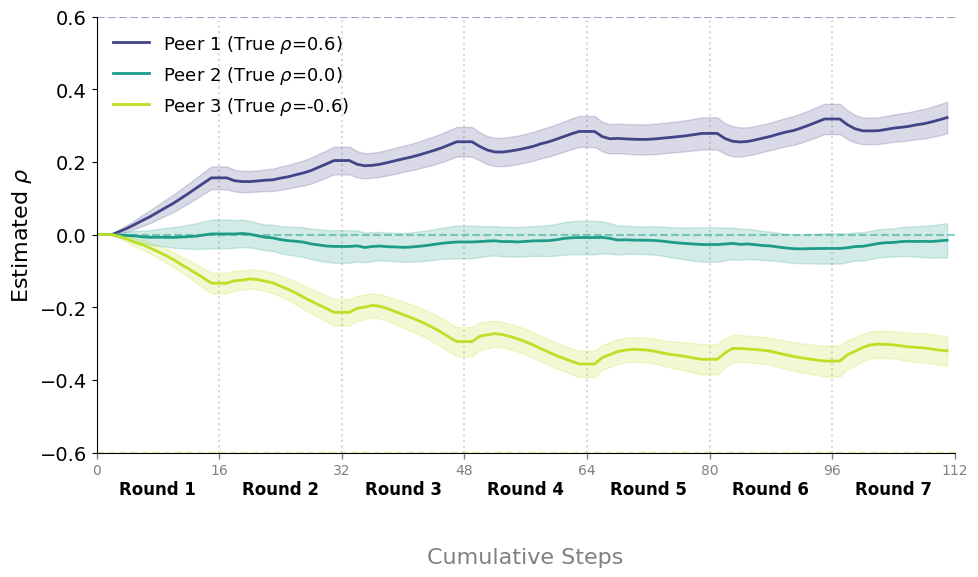

Saved final_figures/fig6_multiround_rho_continuous.svg


In [46]:
def plot_multiround_rho_continuous(histories, output_path):
    # Filter for SCALE/landmarks_corr
    target_keys = ["landmarks_corr", "SCALE"]
    relevant = []

    # Normalize list of dicts vs loaded numpy array of objects
    clean_histories = []
    for h in histories:
        if isinstance(h, dict):
            clean_histories.append(h)
        else:
            # Handle numpy object
            clean_histories.append({
                'condition': h['condition'],
                'rho_history': h['rho_history'],
                'seed': h['seed'],
                'round': h['round']
            })

    relevant = [h for h in clean_histories if h['condition'] in target_keys]

    if not relevant:
        print("No multi-round histories found for SCALE.")
        return

    # Stitch trajectories by seed
    # Group by seed
    seeds = set(h['seed'] for h in relevant)
    stitched_trajectories = []

    for s in seeds:
        seed_hists = [h for h in relevant if h['seed'] == s]
        seed_hists.sort(key=lambda x: x['round'])

        arrays = [h['rho_history'] for h in seed_hists]
        if arrays:
            stitched = np.concatenate(arrays, axis=0)
            stitched_trajectories.append(stitched)

    # Calculate Mean & CI
    # Find min length
    min_len = min(len(t) for t in stitched_trajectories)
    trimmed = [t[:min_len] for t in stitched_trajectories]
    stack = np.stack(trimmed, axis=0)

    mean_rho = np.mean(stack, axis=0)
    std_rho = np.std(stack, axis=0)
    ci = 1.96 * std_rho / np.sqrt(len(stitched_trajectories))

    steps = np.arange(min_len)
    true_rhos = [0.6, 0.0, -0.6]

    fig, ax = plt.subplots(figsize=(10, 6))

    for i in range(3):
        idx = i + 1
        color = rho_colors[i]
        true_val = true_rhos[i]

        # Updated Label with True Rho value
        ax.plot(steps, mean_rho[:, idx], color=color, linewidth=2,
                label=f"Peer {idx} (True $\\rho$={true_val})")

        ax.fill_between(steps,
                        mean_rho[:, idx] - ci[:, idx],
                        mean_rho[:, idx] + ci[:, idx],
                        color=color, alpha=0.2)
        ax.axhline(true_rhos[i], color=color, linestyle='--', alpha=0.5)

    # --- Axis Formatting (Matching Reward Plot) ---

    # Determine structure
    steps_per_round = len(relevant[0]['rho_history'])
    total_rounds = min_len // steps_per_round

    # Cut space before 0
    ax.set_xlim(0, min_len)

    # Configure Major Ticks (Step Numbers at Round Boundaries)
    boundary_ticks = [r * steps_per_round for r in range(total_rounds + 1)]
    ax.set_xticks(boundary_ticks)
    ax.set_xticklabels(boundary_ticks, fontsize=10, color='gray')

    # Configure Minor Ticks (Round Labels in the Middle)
    center_locs = [r * steps_per_round + (steps_per_round / 2) for r in range(total_rounds)]
    center_labels = [f"Round {r + 1}" for r in range(total_rounds)]

    ax.set_xticks(center_locs, minor=True)
    ax.set_xticklabels(center_labels, minor=True, fontsize=12, fontweight='bold')

    # Styling Ticks
    ax.tick_params(axis='x', which='major', length=4, width=1, colors='gray', direction='out')
    ax.tick_params(axis='x', which='minor', length=0, pad=20, colors='black')

    # Vertical dividers at boundaries
    for r in range(1, total_rounds):
        ax.axvline(r * steps_per_round, color='gray', linestyle=':', alpha=0.3, zorder=0)

    ax.set_ylabel("Estimated $\\rho$")
    ax.set_xlabel("Cumulative Steps", labelpad=35, color='gray')

    # Legend position
    ax.legend(loc='upper left', title=None)
    ax.set_ylim(-0.6, 0.6)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved {output_path}")

plot_multiround_rho_continuous(mr_hist, output_dir / "fig6_multiround_rho_continuous.svg")